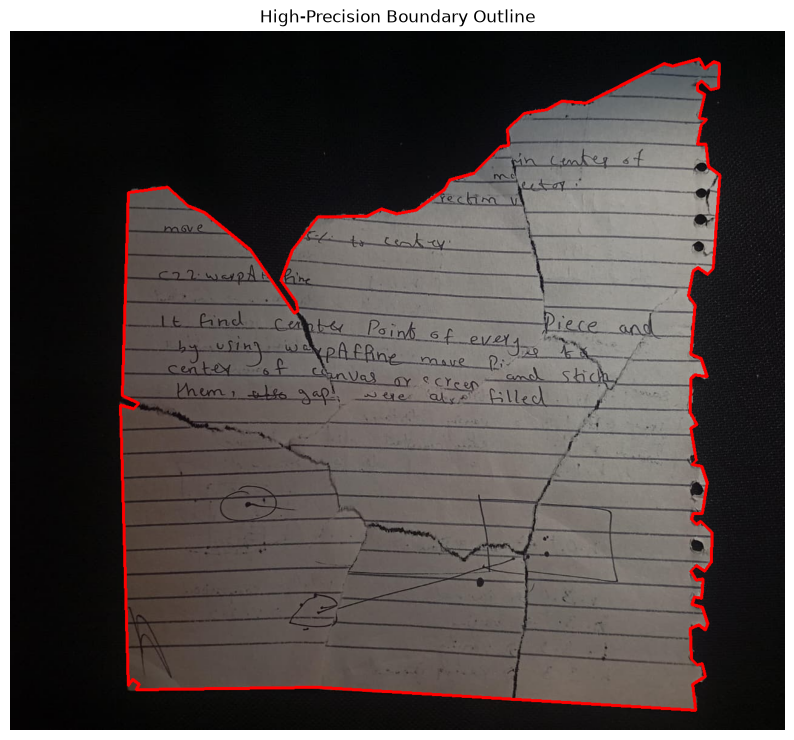

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def get_accurate_contours(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print("Error loading image.")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. Otsu's Thresholding
    _, thresh = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # 2. Solidify internal voids (text & ruling lines touching edges)
    im_floodfill = thresh.copy()
    mask_fill = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(im_floodfill, mask_fill, (0, 0), 255)
    im_floodfill_inv = cv2.bitwise_not(im_floodfill)
    solid_mask = cv2.bitwise_or(thresh, im_floodfill_inv)

    # 3. Morphological Closing with an Elliptical Kernel
    # Smooths out jagged binder holes on the right and bridge tiny tear notches
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    clean_mask = cv2.morphologyEx(solid_mask, cv2.MORPH_CLOSE, kernel)

    # 4. Find Contours
    contours, _ = cv2.findContours(
        clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
    )

    # Filter out minor noise
    min_area = (h * w) * 0.005
    fragments = [c for c in contours if cv2.contourArea(c) > min_area]

    highlighted_img = img_rgb.copy()

    for idx, contour in enumerate(fragments):
        # 5. Smooth out micro-noise (e.g., jagged paper fibers/holes)
        # 0.001 * arcLength keeps the exact tear shape but removes pixel jitter
        epsilon = 0.001 * cv2.arcLength(contour, True)
        smoothed_contour = cv2.approxPolyDP(contour, epsilon, True)

        # Draw refined red contour
        cv2.drawContours(highlighted_img, [smoothed_contour], -1, (255, 0, 0), 3)

    plt.figure(figsize=(10, 10))
    plt.imshow(highlighted_img)
    plt.title("High-Precision Boundary Outline")
    plt.axis("off")
    plt.show()


get_accurate_contours(r"D:\PythonProject1\Intern\Images\img159.jpeg")

In [ ]:
import os
import sys
import tkinter as tk
from tkinter import filedialog, messagebox
import cv2
import numpy as np
from PIL import Image, ImageTk


# ==========================================
# 1. CORE ALGORITHM & MATH ENGINE (CASE 1)
# ==========================================

def display_detected_fragments(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image could not be loaded. Check your file path.")
        return None, None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(
        gray, 250, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    min_area = (h * w) * 0.001
    fragments = [c for c in contours if cv2.contourArea(c) > min_area]

    temporary_storage = []
    for idx, contour in enumerate(fragments):
        mask = np.zeros_like(gray)
        cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)

        piece = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

        x, y, pw, ph = cv2.boundingRect(contour)
        cropped_piece = piece[y : y + ph, x : x + pw]

        cropped_bgr = cv2.cvtColor(cropped_piece, cv2.COLOR_RGB2BGR)

        temporary_storage.append(
            {"img": cropped_bgr, "orig_x": x, "orig_y": y}
        )

    return temporary_storage, w


def get_mask(img):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    return (gray > 15).astype(np.uint8) * 255


def find_best_alignment(canvas, patch):
    """Generically aligns a new patch onto the canvas by finding the translation (dx, dy)
    and slight angular tweak that maximizes edge boundary contact while minimizing overlap.
    """
    m_canvas = get_mask(canvas)
    m_patch = get_mask(patch)

    # Edge contours of patch
    canny_p = cv2.Canny(m_patch, 50, 150)
    y_p, x_p = np.where(canny_p == 255)

    if len(y_p) == 0:
        return 0, 0, float("inf")

    # Downsample points for speed
    if len(y_p) > 350:
        idx = np.linspace(0, len(y_p) - 1, 350, dtype=int)
        y_p, x_p = y_p[idx], x_p[idx]

    dist_out = cv2.distanceTransform(~m_canvas, cv2.DIST_L2, 5)
    dist_in = cv2.distanceTransform(m_canvas, cv2.DIST_L2, 5)

    h_c, w_c = canvas.shape[:2]
    h_p, w_p = patch.shape[:2]

    best_dx, best_dy = 0, 0
    min_score = float("inf")

    # Coarse search across potential bounding overlaps
    step = 8
    for dy in range(-int(h_p * 0.7), int(h_c * 0.9), step):
        for dx in range(-int(w_p * 0.7), int(w_c * 0.9), step):
            sy, sx = y_p + dy, x_p + dx
            valid = (sy >= 0) & (sy < h_c) & (sx >= 0) & (sx < w_c)
            if np.sum(valid) < 10:
                continue

            vy, vx = sy[valid], sx[valid]
            overlap = m_canvas[vy, vx] == 255
            non_overlap_y, non_overlap_x = vy[~overlap], vx[~overlap]

            # Reward edges close to existing boundaries, heavily penalize deep overlaps
            touching = (
                np.sum(dist_out[non_overlap_y, non_overlap_x] <= 5.0)
                if len(non_overlap_y) > 0
                else 0
            )
            deep_overlap = (
                np.sum(dist_in[vy[overlap], vx[overlap]] > 6.0)
                if np.sum(overlap) > 0
                else 0
            )

            score = -touching + (5.0 * deep_overlap)

            if score < min_score:
                min_score = score
                best_dx, best_dy = dx, dy

    # Fine search refinement
    fine_step = 1
    for dy in range(best_dy - step, best_dy + step + 1, fine_step):
        for dx in range(best_dx - step, best_dx + step + 1, fine_step):
            sy, sx = y_p + dy, x_p + dx
            valid = (sy >= 0) & (sy < h_c) & (sx >= 0) & (sx < w_c)
            if np.sum(valid) < 10:
                continue

            vy, vx = sy[valid], sx[valid]
            overlap = m_canvas[vy, vx] == 255
            non_overlap_y, non_overlap_x = vy[~overlap], vx[~overlap]

            touching = (
                np.sum(dist_out[non_overlap_y, non_overlap_x] <= 5.0)
                if len(non_overlap_y) > 0
                else 0
            )
            deep_overlap = (
                np.sum(dist_in[vy[overlap], vx[overlap]] > 6.0)
                if np.sum(overlap) > 0
                else 0
            )

            score = -touching + (5.0 * deep_overlap)

            if score < min_score:
                min_score = score
                best_dx, best_dy = dx, dy

    return best_dx, best_dy, min_score


def merge_patch_to_canvas(canvas, patch, dx, dy):
    """Generically expands canvas if needed and overlays patch onto canvas at (dx, dy)."""
    h_c, w_c = canvas.shape[:2]
    h_p, w_p = patch.shape[:2]

    m_patch = get_mask(patch)

    oy, ox = max(0, -dy), max(0, -dx)
    new_h = max(h_c + oy, h_p + dy + oy)
    new_w = max(w_c + ox, w_p + dx + ox)

    new_canvas = np.zeros((new_h, new_w, 3), dtype=np.uint8)

    # Place existing canvas
    new_canvas[oy : oy + h_c, ox : ox + w_c] = canvas

    # Place new patch
    patch_target_y = dy + oy
    patch_target_x = dx + ox

    patch_area = new_canvas[
        patch_target_y : patch_target_y + h_p,
        patch_target_x : patch_target_x + w_p,
    ]
    patch_area[m_patch == 255] = patch[m_patch == 255]

    return new_canvas


def display_final_canvas(raw_fragment_metadata, step_callback=None):
    """Fully generalized dynamic stitching loop using greedy best-match edge search.
    Invokes step_callback(intermediate_canvas, step_number, total_steps) at each iteration.
    """
    if not raw_fragment_metadata:
        return None

    unstitched = [item["img"] for item in raw_fragment_metadata]

    # Sort fragments by size (area) to start with the largest piece as base canvas
    unstitched.sort(
        key=lambda img: np.count_nonzero(get_mask(img)), reverse=True
    )

    canvas = unstitched.pop(0)
    total_steps = len(unstitched)
    current_step = 0

    # Show initial state (base fragment)
    if step_callback:
        step_callback(canvas, current_step, total_steps)

    # Greedily pick and stitch the next best-fitting fragment
    while unstitched:
        best_candidate_idx = 0
        best_dx, best_dy = 0, 0
        best_score = float("inf")

        for idx, patch in enumerate(unstitched):
            dx, dy, score = find_best_alignment(canvas, patch)
            if score < best_score:
                best_score = score
                best_dx, best_dy = dx, dy
                best_candidate_idx = idx

        # Merge the winning piece
        winning_patch = unstitched.pop(best_candidate_idx)
        canvas = merge_patch_to_canvas(canvas, winning_patch, best_dx, best_dy)

        current_step += 1
        # Trigger step visualization
        if step_callback:
            step_callback(canvas, current_step, total_steps)

    return canvas


def apply_inpainting_transformation(canvas):
    gray = cv2.cvtColor(canvas, cv2.COLOR_BGR2GRAY)
    paper_mask = (gray > 15).astype(np.uint8) * 255

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    closed_paper = cv2.morphologyEx(paper_mask, cv2.MORPH_CLOSE, kernel)
    gaps_mask = cv2.bitwise_and(closed_paper, cv2.bitwise_not(paper_mask))

    _, bright_seams = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)
    seams_mask = cv2.bitwise_or(gaps_mask, bright_seams)
    seams_mask = cv2.bitwise_and(seams_mask, closed_paper)

    inpainted = cv2.inpaint(
        canvas, seams_mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA
    )

    lab = cv2.cvtColor(inpainted, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    enhanced_bgr = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2BGR)

    enhanced_gray = cv2.cvtColor(enhanced_bgr, cv2.COLOR_BGR2GRAY)
    binarized = cv2.adaptiveThreshold(
        enhanced_gray,
        200,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        3,
        2,
    )

    return binarized


PALETTE_BG = "#F8FAFC"          # Soft Chalk Background
PALETTE_SIDEBAR = "#FFFFFF"     # Crisp White Sidebar
PALETTE_WORKSPACE = "#F1F5F9"   # Off-white Canvas Frame
PALETTE_BORDER = "#E2E8F0"      # Subtle Gray Division Lines

PALETTE_PRIMARY = "#4F46E5"     # Deep Indigo Accent
PALETTE_PRIMARY_HOVER = "#4338CA"
PALETTE_EMERALD = "#10B981"     # Mint Green
PALETTE_EMERALD_HOVER = "#059669"
PALETTE_SLATE = "#64748B"       # Slate Gray Secondary Text
PALETTE_TEXT_DARK = "#0F172A"   # Midnight Primary Text


# ==========================================
# 3. APPLICATION WINDOWS
# ==========================================

class ApplicationWindow:

    def __init__(self):
        self.root = tk.Tk()
        self.root.title("Paper Studio — Document Reconstruction Engine")
        self.root.geometry("840x640")
        self.root.configure(bg=PALETTE_BG)
        self.root.resizable(False, False)

        self.selected_path = None
        self.input_preview_photo = None
        self.stitched_canvas = None
        
        self.step_history = []
        self.current_step_index = 0

        self.setup_ui_layout()

    def setup_ui_layout(self):
        self.sidebar = tk.Frame(
            self.root, bg=PALETTE_SIDEBAR, width=280, highlightbackground=PALETTE_BORDER, highlightthickness=1
        )
        self.sidebar.pack(side=tk.LEFT, fill=tk.Y)
        self.sidebar.pack_propagate(False)

        brand_frame = tk.Frame(self.sidebar, bg=PALETTE_SIDEBAR, padx=20, pady=24)
        brand_frame.pack(fill=tk.X)

        lbl_logo = tk.Label(
            brand_frame,
            text="Paper Studio",
            font=("Segoe UI", 16, "bold"),
            bg=PALETTE_SIDEBAR,
            fg=PALETTE_TEXT_DARK,
            anchor="w",
        )
        lbl_logo.pack(fill=tk.X)

        lbl_sub = tk.Label(
            brand_frame,
            text="Document Reconstruction Engine",
            font=("Segoe UI", 8),
            bg=PALETTE_SIDEBAR,
            fg=PALETTE_SLATE,
            anchor="w",
        )
        lbl_sub.pack(fill=tk.X, pady=(2, 0))

        controls_group = tk.Frame(self.sidebar, bg=PALETTE_SIDEBAR, padx=20)
        controls_group.pack(fill=tk.X, pady=(10, 0))

        lbl_step1 = tk.Label(
            controls_group,
            text="1. SOURCE DOCUMENT",
            font=("Segoe UI", 8, "bold"),
            bg=PALETTE_SIDEBAR,
            fg=PALETTE_PRIMARY,
            anchor="w",
        )
        lbl_step1.pack(fill=tk.X, pady=(0, 6))

        self.btn_select_file = tk.Button(
            controls_group,
            text="Choose Image File...",
            font=("Segoe UI", 9, "bold"),
            bg=PALETTE_PRIMARY,
            fg="white",
            activebackground=PALETTE_PRIMARY_HOVER,
            activeforeground="white",
            bd=0,
            padx=14,
            pady=8,
            cursor="hand2",
            anchor="w",
            command=self.browse_file,
        )
        self.btn_select_file.pack(fill=tk.X)

        self.lbl_file_name = tk.Label(
            controls_group,
            text="No file selected",
            font=("Segoe UI", 8, "italic"),
            bg=PALETTE_SIDEBAR,
            fg=PALETTE_SLATE,
            anchor="w",
            wraplength=230,
            justify="left",
        )
        self.lbl_file_name.pack(fill=tk.X, pady=(6, 18))

        lbl_step2 = tk.Label(
            controls_group,
            text="2. RECONSTRUCTION",
            font=("Segoe UI", 8, "bold"),
            bg=PALETTE_SIDEBAR,
            fg=PALETTE_PRIMARY,
            anchor="w",
        )
        lbl_step2.pack(fill=tk.X, pady=(0, 6))

        self.btn_run_stitch = tk.Button(
            controls_group,
            text="🧩 Stitch Fragments",
            font=("Segoe UI", 9, "bold"),
            bg=PALETTE_EMERALD,
            fg="white",
            activebackground=PALETTE_EMERALD_HOVER,
            activeforeground="white",
            disabledforeground="#94A3B8",
            bd=0,
            padx=14,
            pady=8,
            cursor="hand2",
            state=tk.DISABLED,
            anchor="w",
            command=self.process_image,
        )
        self.btn_run_stitch.pack(fill=tk.X)

        self.btn_open_viewer = tk.Button(
            controls_group,
            text="🔍 View Final Output & Inpaint ▶",
            font=("Segoe UI", 8, "bold"),
            bg=PALETTE_PRIMARY,
            fg="white",
            activebackground=PALETTE_PRIMARY_HOVER,
            activeforeground="white",
            bd=0,
            padx=10,
            pady=8,
            cursor="hand2",
            anchor="w",
            command=self.open_result_viewer,
        )

        status_frame = tk.Frame(self.sidebar, bg=PALETTE_SIDEBAR, padx=20, pady=20)
        status_frame.pack(side=tk.BOTTOM, fill=tk.X)

        self.lbl_status = tk.Label(
            status_frame,
            text="Status: Ready",
            font=("Segoe UI", 8, "bold"),
            bg=PALETTE_SIDEBAR,
            fg=PALETTE_SLATE,
            anchor="w",
            wraplength=230,
            justify="left",
        )
        self.lbl_status.pack(fill=tk.X)

        workspace = tk.Frame(self.root, bg=PALETTE_BG, padx=20, pady=20)
        workspace.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True)

        self.card = tk.Frame(
            workspace, bg=PALETTE_WORKSPACE, highlightbackground=PALETTE_BORDER, highlightthickness=1
        )
        self.card.pack(fill=tk.BOTH, expand=True)

        self.lbl_card_title = tk.Label(
            self.card,
            text="Input Preview",
            font=("Segoe UI", 9, "bold"),
            bg=PALETTE_WORKSPACE,
            fg=PALETTE_SLATE,
            padx=16,
            pady=12,
            anchor="w",
        )
        self.lbl_card_title.pack(fill=tk.X)

        self.lbl_preview = tk.Label(
            self.card,
            text="🖼️ No Document Loaded\n\nClick 'Choose Image File...' on the left panel to begin.",
            font=("Segoe UI", 9),
            bg=PALETTE_WORKSPACE,
            fg=PALETTE_SLATE,
        )
        self.lbl_preview.pack(fill=tk.BOTH, expand=True)

        self.nav_frame = tk.Frame(self.card, bg=PALETTE_WORKSPACE, pady=10)
        self.nav_frame.pack(fill=tk.X, side=tk.BOTTOM)

        self.btn_prev_step = tk.Button(
            self.nav_frame,
            text="◀ Previous Step",
            font=("Segoe UI", 8, "bold"),
            bg=PALETTE_SLATE,
            fg="white",
            activebackground="#475569",
            activeforeground="white",
            disabledforeground="#94A3B8",
            bd=0,
            padx=12,
            pady=6,
            cursor="hand2",
            state=tk.DISABLED,
            command=self.show_previous_step,
        )
        self.btn_prev_step.pack(side=tk.LEFT, padx=(20, 5))

        self.lbl_step_counter = tk.Label(
            self.nav_frame,
            text="Step 0 of 0",
            font=("Segoe UI", 8, "bold"),
            bg=PALETTE_WORKSPACE,
            fg=PALETTE_SLATE,
        )
        self.lbl_step_counter.pack(side=tk.LEFT, expand=True)

        self.btn_next_step = tk.Button(
            self.nav_frame,
            text="Next Step ▶",
            font=("Segoe UI", 8, "bold"),
            bg=PALETTE_SLATE,
            fg="white",
            activebackground="#475569",
            activeforeground="white",
            disabledforeground="#94A3B8",
            bd=0,
            padx=12,
            pady=6,
            cursor="hand2",
            state=tk.DISABLED,
            command=self.show_next_step,
        )
        self.btn_next_step.pack(side=tk.RIGHT, padx=(5, 20))

    def browse_file(self):
        file_path = filedialog.askopenfilename(
            title="Select Image File",
            filetypes=[
                ("Image Files", "*.jpg *.jpeg *.png *.bmp *.tiff"),
                ("All Files", "*.*"),
            ],
        )
        if file_path:
            self.selected_path = file_path
            self.lbl_file_name.config(
                text=os.path.basename(file_path), fg=PALETTE_TEXT_DARK, font=("Segoe UI", 8, "bold")
            )
            self.btn_run_stitch.config(state=tk.NORMAL, bg=PALETTE_EMERALD)
            self.btn_open_viewer.pack_forget()
            self.lbl_status.config(
                text="Status: Image loaded. Ready to stitch.",
                fg=PALETTE_PRIMARY,
            )

            self.step_history = []
            self.current_step_index = 0
            self.stitched_canvas = None
            self.update_nav_buttons()

            pil_img = Image.open(file_path)
            pil_img.thumbnail((460, 340))
            self.input_preview_photo = ImageTk.PhotoImage(pil_img)
            self.lbl_preview.config(
                image=self.input_preview_photo, text="", bg=PALETTE_WORKSPACE
            )

    def record_stitch_step(self, intermediate_canvas, current_step, total_steps):
        self.step_history.append(intermediate_canvas.copy())
        self.current_step_index = len(self.step_history) - 1

        self.render_step_frame()
        self.lbl_status.config(
            text=f"Status: ⏳ Stitching step {current_step}/{total_steps}...",
            fg="#D97706",
        )
        self.root.update()

    def render_step_frame(self):
        if not self.step_history:
            return

        canvas_img = self.step_history[self.current_step_index]
        img_rgb = cv2.cvtColor(canvas_img, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(img_rgb)
        pil_img.thumbnail((460, 340))
        self.input_preview_photo = ImageTk.PhotoImage(pil_img)

        total_steps = len(self.step_history) - 1
        
        if self.current_step_index == total_steps and self.stitched_canvas is not None:
            self.lbl_card_title.config(
                text=f"Final Assembly Complete — Step {self.current_step_index} of {total_steps}"
            )
        else:
            self.lbl_card_title.config(
                text=f"Assembly Progress — Step {self.current_step_index} of {total_steps}"
            )

        self.lbl_preview.config(image=self.input_preview_photo, text="", bg=PALETTE_WORKSPACE)
        self.lbl_step_counter.config(
            text=f"Step {self.current_step_index} of {total_steps}"
        )
        self.update_nav_buttons()

    def show_previous_step(self):
        if self.current_step_index > 0:
            self.current_step_index -= 1
            self.render_step_frame()

    def show_next_step(self):
        if self.current_step_index < len(self.step_history) - 1:
            self.current_step_index += 1
            self.render_step_frame()

    def update_nav_buttons(self):
        total = len(self.step_history)
        if total <= 1:
            self.btn_prev_step.config(state=tk.DISABLED, bg="#CBD5E1")
            self.btn_next_step.config(state=tk.DISABLED, bg="#CBD5E1")
            return

        if self.current_step_index > 0:
            self.btn_prev_step.config(state=tk.NORMAL, bg=PALETTE_SLATE)
        else:
            self.btn_prev_step.config(state=tk.DISABLED, bg="#CBD5E1")

        if self.current_step_index < total - 1:
            self.btn_next_step.config(state=tk.NORMAL, bg=PALETTE_SLATE)
        else:
            self.btn_next_step.config(state=tk.DISABLED, bg="#CBD5E1")

    def process_image(self):
        if not self.selected_path:
            return

        self.step_history = []
        self.current_step_index = 0
        self.btn_open_viewer.pack_forget()

        self.btn_run_stitch.config(state=tk.DISABLED, bg="#CBD5E1")
        self.btn_select_file.config(state=tk.DISABLED)
        self.lbl_status.config(
            text="Status: ⏳ Detecting fragments...",
            fg="#D97706",
        )
        self.root.update()

        raw_fragment_metadata, _ = display_detected_fragments(
            self.selected_path
        )
        if not raw_fragment_metadata:
            messagebox.showerror(
                "Error",
                "No distinct paper fragments found or image path error.",
            )
            self.reset_ui()
            return

        self.stitched_canvas = display_final_canvas(
            raw_fragment_metadata, step_callback=self.record_stitch_step
        )

        self.btn_select_file.config(state=tk.NORMAL)
        self.btn_run_stitch.config(state=tk.NORMAL, bg=PALETTE_EMERALD)
        
        self.btn_open_viewer.pack(fill=tk.X, pady=(10, 0))

        self.lbl_status.config(
            text="Status: ✅ Assembly Complete! Use ◀ ▶ buttons below to review all steps.",
            fg=PALETTE_EMERALD,
        )

    def open_result_viewer(self):
        if self.stitched_canvas is not None:
            self.root.withdraw()
            ResultViewer(self.root, self.stitched_canvas)

    def reset_ui(self):
        self.btn_run_stitch.config(state=tk.NORMAL, bg=PALETTE_EMERALD)
        self.btn_select_file.config(state=tk.NORMAL)
        self.lbl_status.config(text="Status: Ready", fg=PALETTE_SLATE)

    def run(self):
        self.root.mainloop()


class ResultViewer:

    def __init__(self, main_root, stitched_img):
        self.main_root = main_root
        self.stitched_img = stitched_img
        self.current_display_img = stitched_img
        self.inpainted_img = None

        self.window = tk.Toplevel()
        self.window.title("Paper Studio — Stitched Output Viewer")
        self.window.geometry("860x700")
        self.window.configure(bg=PALETTE_BG)
        self.window.protocol("WM_DELETE_WINDOW", self.exit_app)

        self.setup_ui()

    def setup_ui(self):
        header = tk.Frame(self.window, bg=PALETTE_SIDEBAR, padx=20, pady=12, highlightbackground=PALETTE_BORDER, highlightthickness=1)
        header.pack(fill=tk.X, side=tk.TOP)

        self.title_lbl = tk.Label(
            header,
            text="Stitched Result",
            font=("Segoe UI", 12, "bold"),
            bg=PALETTE_SIDEBAR,
            fg=PALETTE_TEXT_DARK,
        )
        self.title_lbl.pack(side=tk.LEFT)

        btn_exit = tk.Button(
            header,
            text="Close App",
            font=("Segoe UI", 9, "bold"),
            bg="#EF4444",
            fg="white",
            activebackground="#DC2626",
            activeforeground="white",
            bd=0,
            padx=14,
            pady=6,
            cursor="hand2",
            command=self.exit_app,
        )
        btn_exit.pack(side=tk.RIGHT, padx=(10, 0))

        btn_back = tk.Button(
            header,
            text="↩ Back to Steps",
            font=("Segoe UI", 9, "bold"),
            bg=PALETTE_SLATE,
            fg="white",
            activebackground="#475569",
            activeforeground="white",
            bd=0,
            padx=14,
            pady=6,
            cursor="hand2",
            command=self.back_to_main,
        )
        btn_back.pack(side=tk.RIGHT, padx=(10, 0))

        btn_save = tk.Button(
            header,
            text="💾 Save Image",
            font=("Segoe UI", 9, "bold"),
            bg=PALETTE_EMERALD,
            fg="white",
            activebackground=PALETTE_EMERALD_HOVER,
            activeforeground="white",
            bd=0,
            padx=14,
            pady=6,
            cursor="hand2",
            command=self.save_image,
        )
        btn_save.pack(side=tk.RIGHT, padx=(10, 0))

        self.btn_inpaint = tk.Button(
            header,
            text="✨ Apply Inpainting",
            font=("Segoe UI", 9, "bold"),
            bg=PALETTE_PRIMARY,
            fg="white",
            activebackground=PALETTE_PRIMARY_HOVER,
            activeforeground="white",
            bd=0,
            padx=14,
            pady=6,
            cursor="hand2",
            command=self.trigger_inpainting,
        )
        self.btn_inpaint.pack(side=tk.RIGHT)

        self.img_card = tk.Frame(
            self.window, bg=PALETTE_WORKSPACE, highlightbackground=PALETTE_BORDER, highlightthickness=1
        )
        self.img_card.pack(fill=tk.BOTH, expand=True, padx=20, pady=20)

        self.lbl_image = tk.Label(self.img_card, bg=PALETTE_WORKSPACE, bd=0)
        self.lbl_image.pack(expand=True, anchor="center", padx=10, pady=10)

        self.render_image(self.stitched_img)

    def render_image(self, img_array):
        if len(img_array.shape) == 2:
            img_rgb = cv2.cvtColor(img_array, cv2.COLOR_GRAY2RGB)
        else:
            img_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

        pil_img = Image.fromarray(img_rgb)
        pil_img.thumbnail((800, 560))
        self.photo = ImageTk.PhotoImage(pil_img)

        self.lbl_image.config(image=self.photo)

    def trigger_inpainting(self):
        if self.inpainted_img is None:
            self.inpainted_img = apply_inpainting_transformation(self.stitched_img)
            self.current_display_img = self.inpainted_img
            self.title_lbl.config(text="Inpainted & Binarized Output")
            self.btn_inpaint.config(text="🔄 Show Raw Stitched")
        else:
            if np.array_equal(self.current_display_img, self.inpainted_img):
                self.current_display_img = self.stitched_img
                self.title_lbl.config(text="Stitched Result")
                self.btn_inpaint.config(text="✨ Apply Inpainting")
            else:
                self.current_display_img = self.inpainted_img
                self.title_lbl.config(text="Inpainted & Binarized Output")
                self.btn_inpaint.config(text="🔄 Show Raw Stitched")

        self.render_image(self.current_display_img)

    def save_image(self):
        file_path = filedialog.asksaveasfilename(
            defaultextension=".png",
            filetypes=[("PNG Image", "*.png"), ("JPEG Image", "*.jpg"), ("All Files", "*.*")],
        )
        if file_path:
            cv2.imwrite(file_path, self.current_display_img)
            messagebox.showinfo("Saved", f"Image saved successfully to:\n{file_path}")

    def back_to_main(self):
        self.window.destroy()
        self.main_root.deiconify()

    def exit_app(self):
        self.window.destroy()
        self.main_root.destroy()
        sys.exit()


if __name__ == "__main__":
    app = ApplicationWindow()
    app.run()